In [1]:
import random
import matplotlib.pyplot as plt

In [25]:
def random_sample(values, weights):
   return random.choices(values, weights=weights, k=1)[0]

def iterative_average(last_avg, x, n):
    return last_avg + (x - last_avg)/n

In [26]:
def plot_convergence(xs, averages):
    epochs = range(1, len(xs) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(epochs, xs, color='#1f77b4', s=15)
    plt.scatter(epochs, averages, color="#8B8000", s=5)
    
    # plt.title(f'Convergence of {label} over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

In [27]:
values = [-1, 1]
p_0 = [0.5, 0.5]
xs= [random_sample(values, p_0)]
avg = [xs[-1]]

for _ in range(1000):
    x = random_sample(values, p_0)
    xs.append(x)
    avg.append(iterative_average(avg[-1], x, len(xs)))

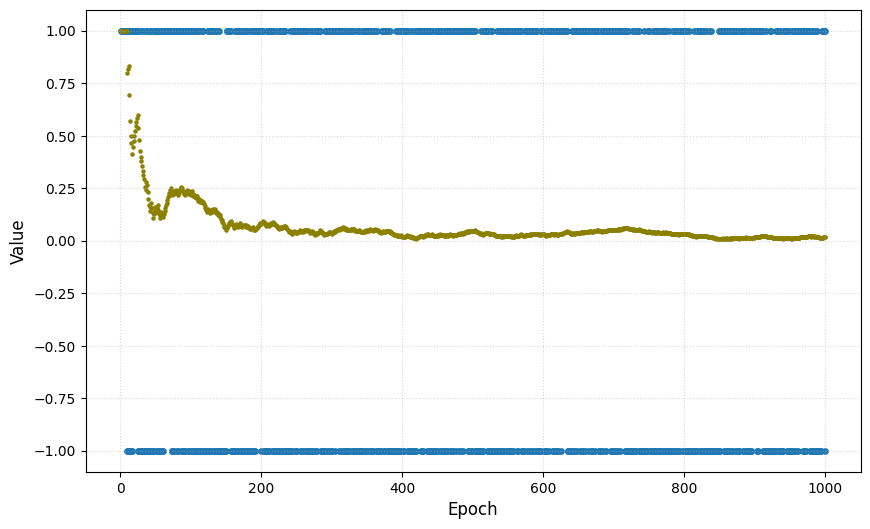

In [28]:
plot_convergence(xs, avg)

# Importance sampling

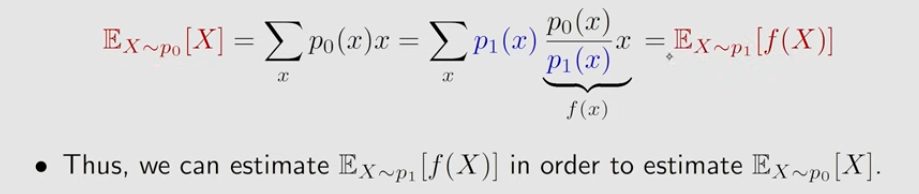

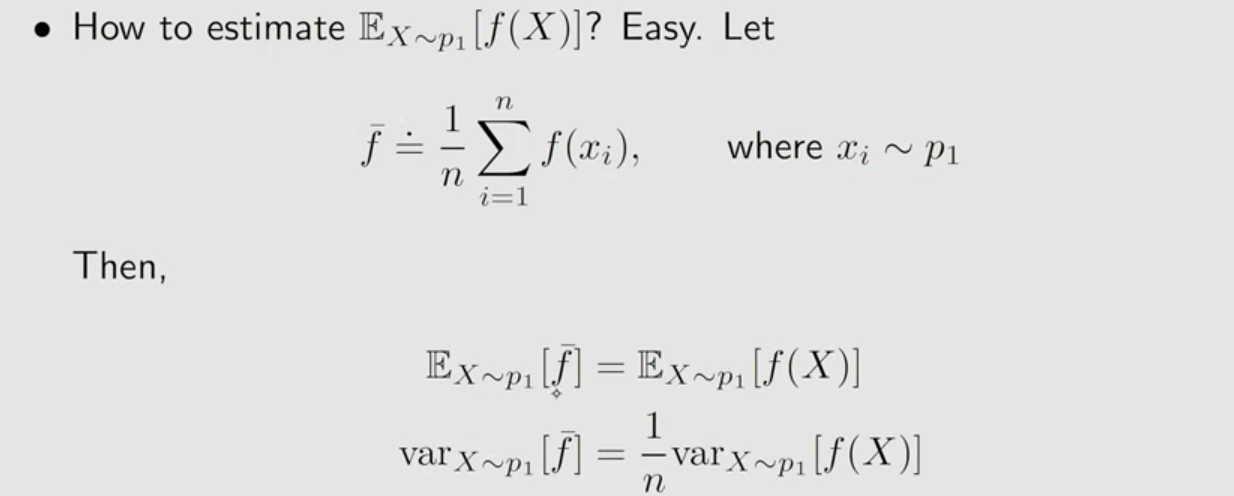

In the "perfect" or real-world implementation, you usually know the formula (the PDF/PMF) for $p_0$, but you don't know the integral (the expected value/mean) because the space is too complex to calculate manually.

1. Defining the Target $p_0$ as a FunctionIn a real scenario, $p_0$ is a "black box" or a complex probability density function. You don't need to know the outcomes of all samples; you just need to be able to ask the function: "What is the probability of this specific $x$ occurring in the target distribution?"

In [40]:
def plot_convergence(xs, avgs, avgs_imp_sample=None):
    epochs = range(1, len(xs) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(epochs, xs, color='#1f77b4', s=15)
    plt.scatter(epochs, avgs, color="#8B8000", s=5)
    if avgs_imp_sample is not None:
        plt.scatter(epochs, avgs_imp_sample, color="#8B0000", s=5)
    
    # plt.title(f'Convergence of {label} over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

In [46]:
values = [-1, 1]
p_1 = [0.2, 0.8]
xs= [random_sample(values, p_1)]

avgs = [xs[-1]]
avgs_imp_sample = [xs[-1]]

for _ in range(1000):
    x = random_sample(values, p_1)
    i = 0 if x == -1 else 1
    w = p_0[i]/p_1[i]
    xs.append(x)
    avgs.append(iterative_average(avgs[-1], x, len(xs)))
    avgs_imp_sample.append(iterative_average(avgs_imp_sample[-1], w*x, len(xs)))

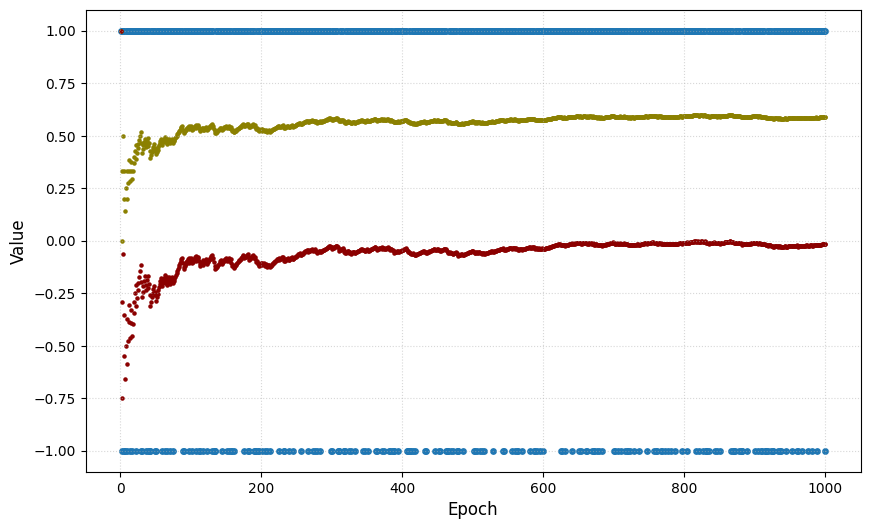

In [47]:
plot_convergence(xs, avgs, avgs_imp_sample)